## Sankey visualisation of study, cell identity and microglia/macrophage subtypes

This notebook visualises relationships between study origin, cell-type or RFP fate-mapping status, and final microglia/macrophage subtype annotations using a Sankey diagram.
For the Hamel dataset, fate-mapping metadata are incorporated to distinguish resident microglia from infiltrating myeloid cells. 

Cell counts are then summarised across three levels:


* Study → Cell type / RFP status → Final subtype

The final interactive visualisation is generated using Plotly.

## Import packages

In [4]:
import scanpy as sc
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

## 1. Load data
Load the integrated AnnData object and the Hamel metadata containing fate-mapping information.

In [5]:
adata_path = "/data/scRNA_adata_final_subtypes_111223_USE_normexpr.h5ad"

hamel_meta_path = "/data/Hamel.ref.csv"
# or if gz:
# hamel_meta_path = "/data/Hamel_GSE159638_cell_annotations.csv.gz"

adata = sc.read_h5ad(adata_path)
meta = pd.read_csv(hamel_meta_path)

# Hamel metadata barcode column
meta = meta.rename(columns={"Unnamed: 0": "barcode"})

## 2. Create RFP-status annotations

The Hamel dataset contains fate-mapping labels that distinguish resident microglia from infiltrating myeloid cells. These labels are converted into more descriptive RFP-status categories and mapped to cell barcodes.

In [6]:
# CREATE RFP STATUS FROM HAMEL METADATA
meta["RFP_status"] = meta["Fate_Map"].map({
    "CreRFP": "RFP+ (Resident MG)",
    "CreYFP": "RFP− (Infiltrating myeloid)",
    "Cx3": "Cx3 (Mixed)"
})

barcode_to_rfp = meta.set_index("barcode")["RFP_status"]

## 3. Integrate RFP information with cell annotations

A copy of the original cell-type annotation is created. For cells from the Hamel study, the original cell-type label is replaced with the corresponding RFP fate-mapping status.

In [7]:
# ADD RFP INFO INTO ADATA
# Make a safe copy of original celltype
adata.obs["orig_celltype_rfp"] = adata.obs["orig_celltype"].astype(str)

# Add RFP status by barcode
adata.obs["RFP_status"] = adata.obs["barcode"].map(barcode_to_rfp)

# Replace ONLY Hamel orig_celltype with RFP labels
hamel_mask = adata.obs["study"] == "Hamel"

adata.obs.loc[hamel_mask, "orig_celltype_rfp"] = (
    adata.obs.loc[hamel_mask, "RFP_status"]
)

## 4. Prepare data for visualisation

Relevant annotation columns are extracted from `adata.obs`. Cells with missing annotations, neuronal labels, or subtypes outside the microglia/macrophage populations are removed.

In [8]:
# PREPARE SANKEY DATA
study_col = "study"
celltype_col = "orig_celltype_rfp"
subtype_col = "final_subtypes"

df = adata.obs[[study_col, celltype_col, subtype_col]].copy()

df = df.dropna(subset=[study_col, celltype_col, subtype_col])
df = df.astype(str)

# Remove NA labels and neurons
df = df[
    (df[celltype_col] != "NA") &
    (~df[celltype_col].str.contains("Neuron", case=False, na=False))
]

# Keep only Microglia and Macrophage subtypes
df = df[
    df[subtype_col].str.startswith(("Microglia", "Macrophages"))
]

## 5. Calculate Sankey links

Cell counts are calculated for transitions between study and cell identity, and between cell identity and final subtype. These counts determine the widths of the Sankey links.

In [9]:
# COUNT LINKS
links12 = (
    df.groupby([study_col, celltype_col])
      .size()
      .reset_index(name="value")
)

links23 = (
    df.groupby([celltype_col, subtype_col])
      .size()
      .reset_index(name="value")
)

## 6. Define Sankey nodes

Unique labels from all three annotation levels are combined into a single node list and assigned numerical values
required by Plotly.

In [10]:
# CREATE NODES

nodes = (
    list(df[study_col].unique()) +
    list(df[celltype_col].unique()) +
    list(df[subtype_col].unique())
)

nodes = list(dict.fromkeys(nodes))
node_map = {node: i for i, node in enumerate(nodes)}

## 7. Define node colours

Study-specific colours are used for dataset nodes, while microglia, macrophage and RFP fate-mapping categories are assigned biologically interpretable colours.

In [11]:
# COLOURS
study_colors = {
    "Milich": "#F4D03F",
    "Hamel": "#E67E22",
    "Brennan": "#2ECC71",
    "Blum": "#3498DB",
    "Floriddia": "#9B59B6",
    "Alkaslasi": "#E91E63",
}

cell_colors = {
    "MG": "#D73027",
    "MCd": "#7B3294",
    "Microglia": "#D73027",
    "Macrophage": "#7B3294",
    "RFP+ (Resident MG)": "#E41A1C",
    "RFP− (Infiltrating myeloid)": "#377EB8",
    "Cx3 (Mixed)": "#4DAF4A",
}

node_colors = []

for n in nodes:
    if n in study_colors:
        node_colors.append(study_colors[n])
    elif n in cell_colors:
        node_colors.append(cell_colors[n])
    elif n.startswith("Microglia"):
        node_colors.append("#D73027")
    elif n.startswith("Macrophages"):
        node_colors.append("#7B3294")
    else:
        node_colors.append("#BDBDBD")

## 8. Construct Sankey links

The categorical labels are converted to nodes, and link colours are derived from their source nodes with partial transparency.

In [12]:
# CREATE LINKS
sources = (
    links12[study_col].map(node_map).tolist() +
    links23[celltype_col].map(node_map).tolist()
)

targets = (
    links12[celltype_col].map(node_map).tolist() +
    links23[subtype_col].map(node_map).tolist()
)

values = (
    links12["value"].tolist() +
    links23["value"].tolist()
)

link_colors = []

for s in sources:
    c = node_colors[s].lstrip("#")
    r = int(c[0:2], 16)
    g = int(c[2:4], 16)
    b = int(c[4:6], 16)
    link_colors.append(f"rgba({r},{g},{b},0.35)")

## 9. Generate the Sankey diagram

The final Sankey diagram shows how cells from each study map onto cell-type or fate-mapping categories and subsequently to microglia/macrophage subtypes.

In [13]:
# PLOT SANKEY
fig = go.Figure(go.Sankey(
    arrangement="snap",

    node=dict(
        label=nodes,
        color=node_colors,
        pad=10,
        thickness=14,
        line=dict(color="black", width=0.3)
    ),

    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
))

fig.update_layout(
    title="Study → Cell Type/RFP Status → Microglia & Macrophage Subtypes",
    width=1100,
    height=600,
    font_size=10,
    margin=dict(l=10, r=10, t=45, b=10),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.write_image("sankey_microglia_macrophages_rfp.png")
#fig.write_html("sankey_microglia_macrophages_rfp.html")

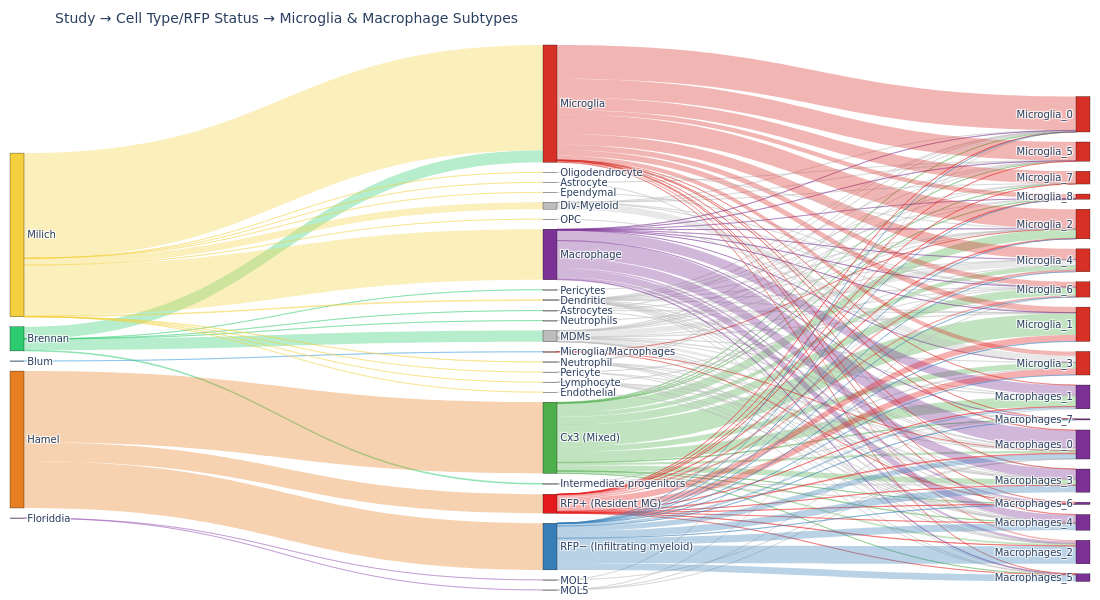

In [14]:
from IPython.display import Image, display

display(Image(filename="sankey_microglia_macrophages_rfp.png"))

## 10. Export interactive figure

Save the Sankey diagram as an interactive HTML file.

In [15]:
#fig.write_html("sankey_microglia_macrophages_rfp.html")

## Environment and package versions

Software environment and package versions used for this analysis.

In [16]:
import sys
import os
import scanpy
import pandas
import plotly
import kaleido

print("Python:", sys.version.split()[0])
print("Python environment:", os.path.basename(os.path.dirname(os.path.dirname(sys.executable))))
print("Conda environment:", os.environ.get("CONDA_DEFAULT_ENV", "Not available"))

print("\nPackage versions:")
print("scanpy:", scanpy.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)
print("kaleido:", getattr(kaleido, "__version__", "version not available"))

Python: 3.8.18
Python environment: MOSCOT_env2
Conda environment: jupyterlab_env2

Package versions:
scanpy: 1.9.8
pandas: 2.0.3
plotly: 5.18.0
kaleido: 0.2.1
